# EDA for Kaggle Dataset

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading in the Kaggle Dataset
filename = os.path.join(os.getcwd(), "US_AQI.csv")
df = pd.read_csv(filename, header= 0)
df

,Unnamed: 0,CBSA Code,Date,AQI,Category,Defining Parameter,Number of Sites Reporting,city_ascii,state_id,state_name,lat,lng,population,density,timezone
0,0,10140,2022-01-01,21,Good,PM2.5,2,Aberdeen,WA,Washington,46.9757,-123.8094,16571.0,588.0,America/Los_Angeles
1,1,10140,2022-01-02,12,Good,PM2.5,2,Aberdeen,WA,Washington,46.9757,-123.8094,16571.0,588.0,America/Los_Angeles
2,2,10140,2022-01-03,18,Good,PM2.5,2,Aberdeen,WA,Washington,46.9757,-123.8094,16571.0,588.0,America/Los_Angeles
3,3,10140,2022-01-04,19,Good,PM2.5,2,Aberdeen,WA,Washington,46.9757,-123.8094,16571.0,588.0,America/Los_Angeles
4,4,10140,2022-01-05,17,Good,PM2.5,2,Aberdeen,WA,Washington,46.9757,-123.8094,16571.0,588.0,America/Los_Angeles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5617320,5718366,49740,1980-12-27,52,Moderate,CO,1,Yuma,AZ,Arizona,32.5995,-114.5491,137612.0,311.0,America/Phoenix
5617321,5718367,49740,1980-12-28,52,Moderate,CO,1,Yuma,AZ,Arizona,32.5995,-114.5491,137612.0,311.0,America/Phoenix
5617322,5718368,49740,1980-12-29,24,Good,CO,1,Yuma,AZ,Arizona,32.5995,-114.5491,137612.0,311.0,America/Phoenix
5617323,5718369,49740,1980-12-30,14,Good,CO,1,Yuma,AZ,Arizona,32.5995,-114.5491,137612.0,311.0,America/Phoenix


In [3]:
df.dtypes

Unnamed: 0                     int64
CBSA Code                      int64
Date                          object
AQI                            int64
Category                      object
Defining Parameter            object
Number of Sites Reporting      int64
city_ascii                    object
state_id                      object
state_name                    object
lat                          float64
lng                          float64
population                   float64
density                      float64
timezone                      object
dtype: object

In [4]:
# Figring out the unique values
df['state_id'].unique()

array(['WA', 'OH', 'GA', 'OR', 'NY', 'NM', 'TX', 'MI', 'WI', 'OK', 'AR',
       'ME', 'CA', 'MD', 'LA', 'NE', 'MT', 'ND', 'VA', 'IL', 'IN', 'MA',
       'CO', 'KY', 'FL', 'UT', 'IA', 'WV', 'SC', 'NC', 'TN', 'NH', 'MS',
       'MO', 'AL', 'MN', 'AZ', 'PA', 'WY', 'PR', 'HI', 'ID', 'NV', 'RI',
       'NJ', 'DC', 'SD', 'AK', 'CT', 'VT', 'KS', 'DE'], dtype=object)

In [5]:
# Seeing how much of the data will be from NY
df['state_id'].value_counts()

state_id
CA    477820
PA    278154
TX    237190
FL    233186
OH    227362
NC    185733
WA    182018
IN    166039
WI    164427
MI    162077
NY    157772
TN    153849
OR    149542
IL    143359
CO    142734
GA    126328
LA    124286
SC    122744
NM    117164
AL    117116
AZ    111174
IA    110044
KY     99590
OK     98140
MT     89478
VA     87380
WV     86434
MS     79323
WY     78875
NV     78870
MN     78134
MO     77076
UT     75864
CT     66294
ID     65881
AR     65177
NH     62663
MA     61237
ME     53216
MD     48876
NJ     45317
ND     43512
KS     43055
NE     40581
SD     39998
AK     37674
VT     28800
PR     27934
HI     25617
DC     15438
RI     15431
DE     11342
Name: count, dtype: int64

In [6]:
# Targeting New York values
ny_condition = df['state_id'] == 'NY'
ny_df = df[ny_condition]
ny_df.head()

,Unnamed: 0,CBSA Code,Date,AQI,Category,Defining Parameter,Number of Sites Reporting,city_ascii,state_id,state_name,lat,lng,population,density,timezone
299,299,10580,2022-01-01,62,Moderate,PM2.5,3,Albany,NY,New York,42.6664,-73.7987,590823.0,1747.0,America/New_York
300,300,10580,2022-01-02,29,Good,Ozone,3,Albany,NY,New York,42.6664,-73.7987,590823.0,1747.0,America/New_York
301,301,10580,2022-01-03,29,Good,Ozone,3,Albany,NY,New York,42.6664,-73.7987,590823.0,1747.0,America/New_York
302,302,10580,2022-01-04,26,Good,Ozone,3,Albany,NY,New York,42.6664,-73.7987,590823.0,1747.0,America/New_York
303,303,10580,2022-01-05,56,Moderate,PM2.5,3,Albany,NY,New York,42.6664,-73.7987,590823.0,1747.0,America/New_York


In [7]:
# Checking for missingness
nan_count = np.sum(ny_df.isnull(), axis = 0)
nan_detected = df.columns[nan_count != 0]
nan_detected

Index([], dtype='object')

In [8]:
ny_df['CBSA Code'].unique()

array([10580, 15380, 18500, 27060, 27460, 35620, 40380, 45060, 46540,
       48060, 21300, 28740, 36300, 13780, 26460, 24020])

In [9]:
# finding correlation
ny_df['Category'].unique() # One-Hot Encode

array(['Moderate', 'Good', 'Unhealthy for Sensitive Groups', 'Unhealthy',
       'Very Unhealthy'], dtype=object)

In [10]:
ny_df['Defining Parameter'].unique() # One Hot Encode

array(['PM2.5', 'Ozone', 'NO2', 'CO', 'PM10'], dtype=object)

In [11]:
ny_df['city_ascii'].unique() #One Hot Encode?

array(['Albany', 'Buffalo', 'Corning', 'Ithaca', 'Jamestown', 'New York',
       'Rochester', 'Syracuse', 'Utica', 'Watertown', 'Elmira',
       'Kingston', 'Ogdensburg', 'Binghamton', 'Hudson', 'Glens Falls'],
      dtype=object)

In [ ]:
ny_df['lat'].unique()

array([42.6664, 42.9018, 42.147 , 42.4442, 42.0976, 40.6943, 43.168 ,
       43.0407, 43.0962, 43.9734, 42.0938, 41.9295, 44.7088, 42.1014,
       42.2515, 43.3109])

In [ ]:
ny_df['Number of Sites Reporting'].unique() # Combine into groups of: <=10, 11-20, 30-40, 40+

array([ 3,  2,  4,  5,  1, 21, 23, 20, 22, 24, 25, 35, 33, 32, 34, 31, 30,
       36, 38, 37, 39, 40, 41, 42, 43, 44, 29, 28,  6, 47, 45, 46,  7,  8,
       48, 50, 49, 18, 27, 52, 51, 54, 53, 56, 55, 58, 57, 59, 60, 61,  9,
       62, 26, 14, 63, 65, 64, 15, 16, 12, 13, 17, 11, 19])

In [ ]:
ny_df['CBSA Code'].unique() # Combine into groups of: <=10, 11-20, 30-40, 40+

array([10580, 15380, 18500, 27060, 27460, 35620, 40380, 45060, 46540,
       48060, 21300, 28740, 36300, 13780, 26460, 24020])

In [ ]:
# dropping some features
drop_columns = ['Unnamed: 0', 'timezone', 'lat', 'lng', 'state_name'] # removing state_name since i have state_id
ny_df.drop(columns=drop_columns, inplace=True)

/tmp/ipykernel_71298/2063390611.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ny_df.drop(columns=drop_columns, inplace=True)


In [ ]:
ny_df.head()

,CBSA Code,Date,AQI,Category,Defining Parameter,Number of Sites Reporting,city_ascii,state_id,population,density
299,10580,2022-01-01,62,Moderate,PM2.5,3,Albany,NY,590823.0,1747.0
300,10580,2022-01-02,29,Good,Ozone,3,Albany,NY,590823.0,1747.0
301,10580,2022-01-03,29,Good,Ozone,3,Albany,NY,590823.0,1747.0
302,10580,2022-01-04,26,Good,Ozone,3,Albany,NY,590823.0,1747.0
303,10580,2022-01-05,56,Moderate,PM2.5,3,Albany,NY,590823.0,1747.0


In [17]:
ny_df['Date'] = pd.to_datetime(ny_df['Date'])

/tmp/ipykernel_71298/2597123253.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ny_df['Date'] = pd.to_datetime(ny_df['Date'])


In [ ]:
ny_df['Year'] = ny_df['Date'].dt.year
ny_df['Month'] = ny_df['Date'].dt.month
ny_df['Day'] = ny_df['Date'].dt.day

/tmp/ipykernel_71298/2292284324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ny_df['Year'] = ny_df['Date'].dt.year
/tmp/ipykernel_71298/2292284324.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ny_df['Month'] = ny_df['Date'].dt.month
/tmp/ipykernel_71298/2292284324.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [ ]:
ny_df

,CBSA Code,Date,AQI,Category,Defining Parameter,Number of Sites Reporting,city_ascii,state_id,population,density,Year,Month,Day
299,10580,2022-01-01,62,Moderate,PM2.5,3,Albany,NY,590823.0,1747.0,2022,1,1
300,10580,2022-01-02,29,Good,Ozone,3,Albany,NY,590823.0,1747.0,2022,1,2
301,10580,2022-01-03,29,Good,Ozone,3,Albany,NY,590823.0,1747.0,2022,1,3
302,10580,2022-01-04,26,Good,Ozone,3,Albany,NY,590823.0,1747.0,2022,1,4
303,10580,2022-01-05,56,Moderate,PM2.5,3,Albany,NY,590823.0,1747.0,2022,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5611291,46540,1980-12-27,17,Good,CO,2,Utica,NY,112948.0,1384.0,1980,12,27
5611292,46540,1980-12-28,21,Good,Ozone,2,Utica,NY,112948.0,1384.0,1980,12,28
5611293,46540,1980-12-29,27,Good,CO,2,Utica,NY,112948.0,1384.0,1980,12,29
5611294,46540,1980-12-30,23,Good,CO,2,Utica,NY,112948.0,1384.0,1980,12,30


In [ ]:
ny_df.dtypes

CBSA Code                             int64
Date                         datetime64[ns]
AQI                                   int64
Category                             object
Defining Parameter                   object
Number of Sites Reporting             int64
city_ascii                           object
state_id                             object
population                          float64
density                             float64
Year                                  int32
Month                                 int32
Day                                   int32
dtype: object

In [ ]:
ny_df['Year'] = ny_df['Year'].astype('int64')
ny_df['Month'] = ny_df['Month'].astype('int64')
ny_df['Day'] = ny_df['Day'].astype('int64')
ny_df.dtypes

/tmp/ipykernel_71298/2401738894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ny_df['Year'] = ny_df['Year'].astype('int64')
/tmp/ipykernel_71298/2401738894.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ny_df['Month'] = ny_df['Month'].astype('int64')
/tmp/ipykernel_71298/2401738894.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

CBSA Code                             int64
Date                         datetime64[ns]
AQI                                   int64
Category                             object
Defining Parameter                   object
Number of Sites Reporting             int64
city_ascii                           object
state_id                             object
population                          float64
density                             float64
Year                                  int64
Month                                 int64
Day                                   int64
dtype: object

In [ ]:
year_condition = ny_df['Year'] >= 2019
ny_df = ny_df[year_condition]
CBSA_condition = ny_df['CBSA Code'] == 35620
ny_df = ny_df[CBSA_condition]
ny_df

,CBSA Code,Date,AQI,Category,Defining Parameter,Number of Sites Reporting,city_ascii,state_id,population,density,Year,Month,Day
15819,35620,2022-01-01,43,Good,PM2.5,21,New York,NY,18680025.0,10768.0,2022,1,1
15820,35620,2022-01-02,40,Good,PM2.5,23,New York,NY,18680025.0,10768.0,2022,1,2
15821,35620,2022-01-03,35,Good,PM2.5,20,New York,NY,18680025.0,10768.0,2022,1,3
15822,35620,2022-01-04,44,Good,PM2.5,21,New York,NY,18680025.0,10768.0,2022,1,4
15823,35620,2022-01-05,65,Moderate,PM2.5,23,New York,NY,18680025.0,10768.0,2022,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
464940,35620,2019-12-27,58,Moderate,PM2.5,30,New York,NY,18680025.0,10768.0,2019,12,27
464941,35620,2019-12-28,64,Moderate,PM2.5,30,New York,NY,18680025.0,10768.0,2019,12,28
464942,35620,2019-12-29,62,Moderate,PM2.5,36,New York,NY,18680025.0,10768.0,2019,12,29
464943,35620,2019-12-30,39,Good,NO2,30,New York,NY,18680025.0,10768.0,2019,12,30


AQI is the label 

# Feature Transformation and One Hot Encoding

This step is vital towards creaing cleaner data and gaining more insights
into the data

In [23]:
categories = ['Very Unhealthy','Unhealthy', 'Unhealthy for Sensitive Groups','Moderate', 'Good']
rating = [1, 2, 3, 4, 5]
ny_df.replace(categories, rating, inplace=True)
ny_df.head()

/tmp/ipykernel_71298/4095954744.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ny_df.replace(categories, rating, inplace=True)


,CBSA Code,Date,AQI,Category,Defining Parameter,Number of Sites Reporting,city_ascii,state_id,population,density,Year,Month,Day
15819,35620,2022-01-01,43,5,PM2.5,21,New York,NY,18680025.0,10768.0,2022,1,1
15820,35620,2022-01-02,40,5,PM2.5,23,New York,NY,18680025.0,10768.0,2022,1,2
15821,35620,2022-01-03,35,5,PM2.5,20,New York,NY,18680025.0,10768.0,2022,1,3
15822,35620,2022-01-04,44,5,PM2.5,21,New York,NY,18680025.0,10768.0,2022,1,4
15823,35620,2022-01-05,65,4,PM2.5,23,New York,NY,18680025.0,10768.0,2022,1,5


### Performing One Hot Encoding

In [24]:
# One-Hot Encoding for parameters
df_param = pd.get_dummies(df['Defining Parameter'], prefix='Param_')
ny_df = ny_df.join(df_param)
ny_df.drop(columns = 'Defining Parameter', inplace=True)

# One-Hot Encoding for Cities
# Since here are a lot of cities, this
# this will be narowd down to the top cities
topCity = list(ny_df['city_ascii'].value_counts().head(10).index)
for c in topCity:
    ny_df['city_ascii'+ c] = np.where(ny_df['city_ascii']==c,1,0)
ny_df.drop(columns='city_ascii', inplace=True)

# THIS CODE ENDS UP CREATNG 613 columns
# df_city = pd.get_dummies(df['city_ascii'], prefix='City_')
# ny_df = ny_df.join(df_city)
# ny_df.drop(columns = 'city_ascii', inplace=True)

# One-Hot Encoding for category
# df_cat = pd.get_dummies(df['Category'], prefix='Category_')
# ny_df = ny_df.join(df_cat)
# ny_df.drop(columns = 'Category', inplace=True)

# Testing to see if the code worked
ny_df.head()

,CBSA Code,Date,AQI,Category,Number of Sites Reporting,state_id,population,density,Year,Month,Day,Param__CO,Param__NO2,Param__Ozone,Param__PM10,Param__PM2.5,city_asciiNew York
15819,35620,2022-01-01,43,5,21,NY,18680025.0,10768.0,2022,1,1,False,False,False,False,True,1
15820,35620,2022-01-02,40,5,23,NY,18680025.0,10768.0,2022,1,2,False,False,False,False,True,1
15821,35620,2022-01-03,35,5,20,NY,18680025.0,10768.0,2022,1,3,False,False,False,False,True,1
15822,35620,2022-01-04,44,5,21,NY,18680025.0,10768.0,2022,1,4,False,False,False,False,True,1
15823,35620,2022-01-05,65,4,23,NY,18680025.0,10768.0,2022,1,5,False,False,False,False,True,1


In [ ]:
# Converting the One-Hot Encodings into numbers
col_bool = list(ny_df.select_dtypes(include=['bool']).columns)

for col in col_bool:
    ny_df[col] = ny_df[col].replace({True: 1, False: 0})

ny_df[col_bool]

/tmp/ipykernel_71298/1532589345.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ny_df[col] = ny_df[col].replace({True: 1, False: 0})


,Param__CO,Param__NO2,Param__Ozone,Param__PM10,Param__PM2.5
15819,0,0,0,0,1
15820,0,0,0,0,1
15821,0,0,0,0,1
15822,0,0,0,0,1
15823,0,0,0,0,1
...,...,...,...,...,...
464940,0,0,0,0,1
464941,0,0,0,0,1
464942,0,0,0,0,1
464943,0,1,0,0,0


In [ ]:
ny_dfCorr = ny_df.drop(columns='state_id', axis = 1)
print(ny_dfCorr.corr()['AQI'].sort_values(ascending=False)[:25])

AQI                          1.000000
Number of Sites Reporting    0.134247
Param__Ozone                 0.104915
Day                          0.019848
Month                        0.004527
Param__PM2.5                -0.035773
Param__CO                   -0.071333
Date                        -0.076841
Year                        -0.077050
Param__NO2                  -0.094477
Category                    -0.839723
CBSA Code                         NaN
population                        NaN
density                           NaN
Param__PM10                       NaN
city_asciiNew York                NaN
Name: AQI, dtype: float64


In [27]:
ny_df

,CBSA Code,Date,AQI,Category,Number of Sites Reporting,state_id,population,density,Year,Month,Day,Param__CO,Param__NO2,Param__Ozone,Param__PM10,Param__PM2.5,city_asciiNew York
15819,35620,2022-01-01,43,5,21,NY,18680025.0,10768.0,2022,1,1,0,0,0,0,1,1
15820,35620,2022-01-02,40,5,23,NY,18680025.0,10768.0,2022,1,2,0,0,0,0,1,1
15821,35620,2022-01-03,35,5,20,NY,18680025.0,10768.0,2022,1,3,0,0,0,0,1,1
15822,35620,2022-01-04,44,5,21,NY,18680025.0,10768.0,2022,1,4,0,0,0,0,1,1
15823,35620,2022-01-05,65,4,23,NY,18680025.0,10768.0,2022,1,5,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464940,35620,2019-12-27,58,4,30,NY,18680025.0,10768.0,2019,12,27,0,0,0,0,1,1
464941,35620,2019-12-28,64,4,30,NY,18680025.0,10768.0,2019,12,28,0,0,0,0,1,1
464942,35620,2019-12-29,62,4,36,NY,18680025.0,10768.0,2019,12,29,0,0,0,0,1,1
464943,35620,2019-12-30,39,5,30,NY,18680025.0,10768.0,2019,12,30,0,1,0,0,0,1


Text(0.5, 1.0, 'Feature Importance using Spearman Correlation Matrix Heatmap')

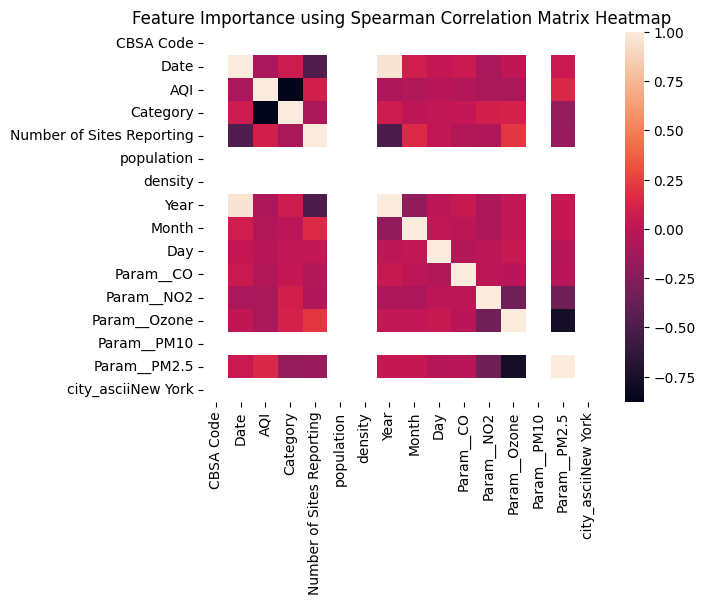

In [28]:
# Plotting correlation on a heatmap
plt.figure()
sns.heatmap(ny_dfCorr.corr(method='spearman'))
plt.title('Feature Importance using Spearman Correlation Matrix Heatmap')

Dropping the values not needed

In [29]:
# Splitting up the data by year?
# year_condition = ny_df['Year'] == 2019
# ny_df = ny_df[year_condition]
drop_column = ['CBSA Code','population','density', 'Param__PM10', 'city_asciiNew York', 'state_id']
ny_df.drop(columns=drop_column, inplace=True)
ny_df.head()

,Date,AQI,Category,Number of Sites Reporting,Year,Month,Day,Param__CO,Param__NO2,Param__Ozone,Param__PM2.5
15819,2022-01-01,43,5,21,2022,1,1,0,0,0,1
15820,2022-01-02,40,5,23,2022,1,2,0,0,0,1
15821,2022-01-03,35,5,20,2022,1,3,0,0,0,1
15822,2022-01-04,44,5,21,2022,1,4,0,0,0,1
15823,2022-01-05,65,4,23,2022,1,5,0,0,0,1


In [32]:
ny_df.to_csv("NY_Kaggle_Data.csv", sep=",", index=False, encoding="utf-8")